In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
y_0 = 0
y_1 = 1
degree = 2
h = 1e-6
x = np.arange(0,1+h,h)
def f(x,U):
    return np.array(U[1], -1*U[1]**2/(U[0] + 1e-4))


In [31]:

def RK_4(p, f,degree):
    U = np.zeros((len(x), degree), dtype=float)

    U[0] = np.array([0, p])

    for i in range(1, len(x)):
        xi = x[i-1]
        Ui = U[i-1]

        k1 = h*f(xi,Ui)
        k2 = h*f(xi + h/2,Ui + k1/2.0)
        k3 = h*f(xi+h/2,Ui + k2/2.0)
        k4 = h*f(xi + h,Ui + k3)

        U[i] = Ui + (k1 + 2*k2 + 2*k3 + k4) / 6

    return U

In [32]:
epsilon = 1e-6
max_iter = 3000

p0 = 0  
p1 = 100

G0 = RK_4(p0, f,degree)[-1,0] - 1
G1 = RK_4(p1, f,degree)[-1,0] - 1
print(G0,G1)
for i in range(1,max_iter+1):

    if abs(G1 - G0) < 1e-12:
        print("Division by zero risk")
        break

    p2 = p1 - G1 * (p1 - p0) / (G1 - G0)

    p0, G0 = p1, G1
    p1 = p2
    G1 = RK_4(p1, f,degree)[-1,0] - 1
    print("iterations:", i)

    if abs(G1) < epsilon:
        print("Converged")
        break

print("p =", p1)


-1.0 170.82818284590127
iterations: 1
Converged
p = 0.5819767068693267


In [33]:
y_rk4 = RK_4(p1,f,degree)[:,0]
y_rk4

array([0.00000000e+00, 5.81976998e-07, 1.16395458e-06, ...,
       9.99996836e-01, 9.99998418e-01, 1.00000000e+00], shape=(1000001,))

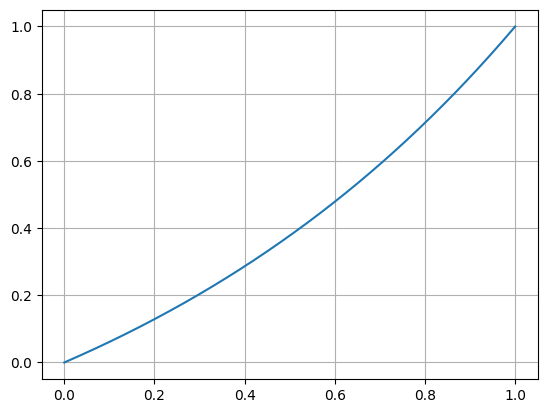

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/tanish/CANM2projects/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/tanish/CANM2projects/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tanish/CANM2projects/venv/lib/python3.12/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/tanish/CANM2projects/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/tanish/CANM2projects/venv/lib/python3.12/site-packages/ipykernel/kernelbase.

In [ ]:
plt.plot(x,y_rk4)
plt.grid()
plt.show()